# Word2Vec Feature Embeddings Demo

This notebook demonstrates automatic feature learning from text using Word2Vec embeddings. Word2Vec exemplifies automatic feature engineering

## Setup: Import Libraries

In [6]:
import gensim.downloader as api
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import pandas as pd
from sklearn.manifold import TSNE

# Set plotting defaults
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("Libraries imported successfully!")

Libraries imported successfully!


---
## Part 1: Load Pretrained Word Embeddings

We use a pretrained model to avoid training time. The model has learned word meanings from large text corpora.

**Model**: GloVe (Global Vectors for Word Representation) - 100-dimensional embeddings trained on Wikipedia + Gigaword corpus

In [5]:
# Load pretrained word embeddings
# This will download ~130MB on first run (takes 1-2 minutes)
print("Loading pretrained word embeddings...")
print("(This may take 1-2 minutes on first run)")

model = api.load("glove-wiki-gigaword-100")

print(f"\nModel loaded successfully!")
print(f"Vocabulary size: {len(model)} words")
print(f"Vector dimensions: {model.vector_size}")
print(f"\nExample: 'king' vector shape: {model['king'].shape}")

Loading pretrained word embeddings...
(This may take 1-2 minutes on first run)


NameError: name 'api' is not defined

---
## Part 2: Word Similarity

**Concept**: Words with similar meanings have similar vector representations. Similarity is measured using cosine similarity (values range from -1 to 1, where 1 = identical).

In [ ]:
# Define word pairs to compare
examples = [
    ('king', 'queen'),      # Related by gender, same role
    ('king', 'man'),        # Gender relationship
    ('king', 'car'),        # Unrelated
    ('computer', 'laptop'), # Similar objects
    ('france', 'paris'),    # Country-capital relationship
    ('run', 'walk'),        # Similar actions
    ('happy', 'sad'),       # Antonyms
    ('doctor', 'nurse')     # Related professions
]

# Calculate and display similarities
print("Word Similarity Scores")
print("=" * 50)
print(f"{'Word 1':<12} {'Word 2':<12} {'Similarity':>12}")
print("-" * 50)

results = []
for word1, word2 in examples:
    similarity = model.similarity(word1, word2)
    results.append({'Word 1': word1, 'Word 2': word2, 'Similarity': similarity})
    print(f"{word1:<12} {word2:<12} {similarity:>12.4f}")

# Create DataFrame for analysis
df_similarity = pd.DataFrame(results)
print("\n Observation: Related words have higher similarity scores (>0.5)")
print("   Unrelated words have lower scores (<0.3)")

Word Similarity Scores
Word 1       Word 2         Similarity
--------------------------------------------------
king         queen              0.7508
king         man                0.5119
king         car                0.2830
computer     laptop             0.7024
france       paris              0.7482
run          walk               0.6683
happy        sad                0.6801
doctor       nurse              0.7522

✅ Observation: Related words have higher similarity scores (>0.5)
   Unrelated words have lower scores (<0.3)


---
## Part 3: Finding Nearest Neighbors

For any word, we can find the most similar words in the embedding space.

In [ ]:
# Query words
query_words = ['king', 'computer', 'happy', 'france']

print("Most Similar Words (Nearest Neighbors)")
print("=" * 70)

for word in query_words:
    print(f"\n🔍 Query: '{word}'")
    print(f"   {'Rank':<6} {'Word':<15} {'Similarity':>12}")
    print("   " + "-" * 40)
    
    # Get top 5 most similar words (excluding the word itself)
    similar = model.most_similar(word, topn=5)
    
    for rank, (similar_word, score) in enumerate(similar, 1):
        print(f"   {rank:<6} {similar_word:<15} {score:>12.4f}")

print("\n Word2Vec captures semantic relationships through co-occurrence patterns")

Most Similar Words (Nearest Neighbors)

🔍 Query: 'king'
   Rank   Word              Similarity
   ----------------------------------------
   1      prince                0.7682
   2      queen                 0.7508
   3      son                   0.7021
   4      brother               0.6986
   5      monarch               0.6978

🔍 Query: 'computer'
   Rank   Word              Similarity
   ----------------------------------------
   1      computers             0.8752
   2      software              0.8373
   3      technology            0.7642
   4      pc                    0.7366
   5      hardware              0.7290

🔍 Query: 'happy'
   Rank   Word              Similarity
   ----------------------------------------
   1      'm                    0.8413
   2      feel                  0.8133
   3      're                   0.8048
   4      i                     0.7938
   5      'll                   0.7916

🔍 Query: 'france'
   Rank   Word              Similarity
   ----------

---
## Part 4: Vector Arithmetic & Analogies

**Famous Example**: king - man + woman ≈ queen

Word embeddings encode relationships as vector operations. This allows us to solve analogies mathematically.

In [ ]:
# Define analogies in format: A is to B as C is to ?
# Mathematically: A - B + C ≈ D
analogies = [
    ('king', 'man', 'woman'),      # king - man + woman = ?
    ('paris', 'france', 'germany'), # paris - france + germany = ?
    ('good', 'better', 'bad'),      # good - better + bad = ?
    ('walk', 'walking', 'run'),     # walk - walking + run = ?
]

print("Vector Arithmetic: Solving Analogies")
print("=" * 70)

for a, b, c in analogies:
    # Find word D such that: A - B + C ≈ D
    # We need to exclude A, B, C from results
    result = model.most_similar(positive=[c, a], negative=[b], topn=1)[0]
    
    print(f"\n {a} - {b} + {c} = ?")
    print(f"   Answer: {result[0]} (similarity: {result[1]:.4f})")

print("\n Analogies emerge naturally from the learned vector space!")
print("   No explicit programming of relationships required.")

Vector Arithmetic: Solving Analogies

📐 king - man + woman = ?
   Answer: queen (similarity: 0.7699)

📐 paris - france + germany = ?
   Answer: berlin (similarity: 0.8846)

📐 good - better + bad = ?
   Answer: thing (similarity: 0.7230)

📐 walk - walking + run = ?
   Answer: allowed (similarity: 0.7007)

✅ Analogies emerge naturally from the learned vector space!
   No explicit programming of relationships required.


---
## Part 5: Visualizing Word Embeddings (2D PCA Projection)

Word embeddings exist in high-dimensional space (100D in this model). We project them to 2D for visualization using PCA.

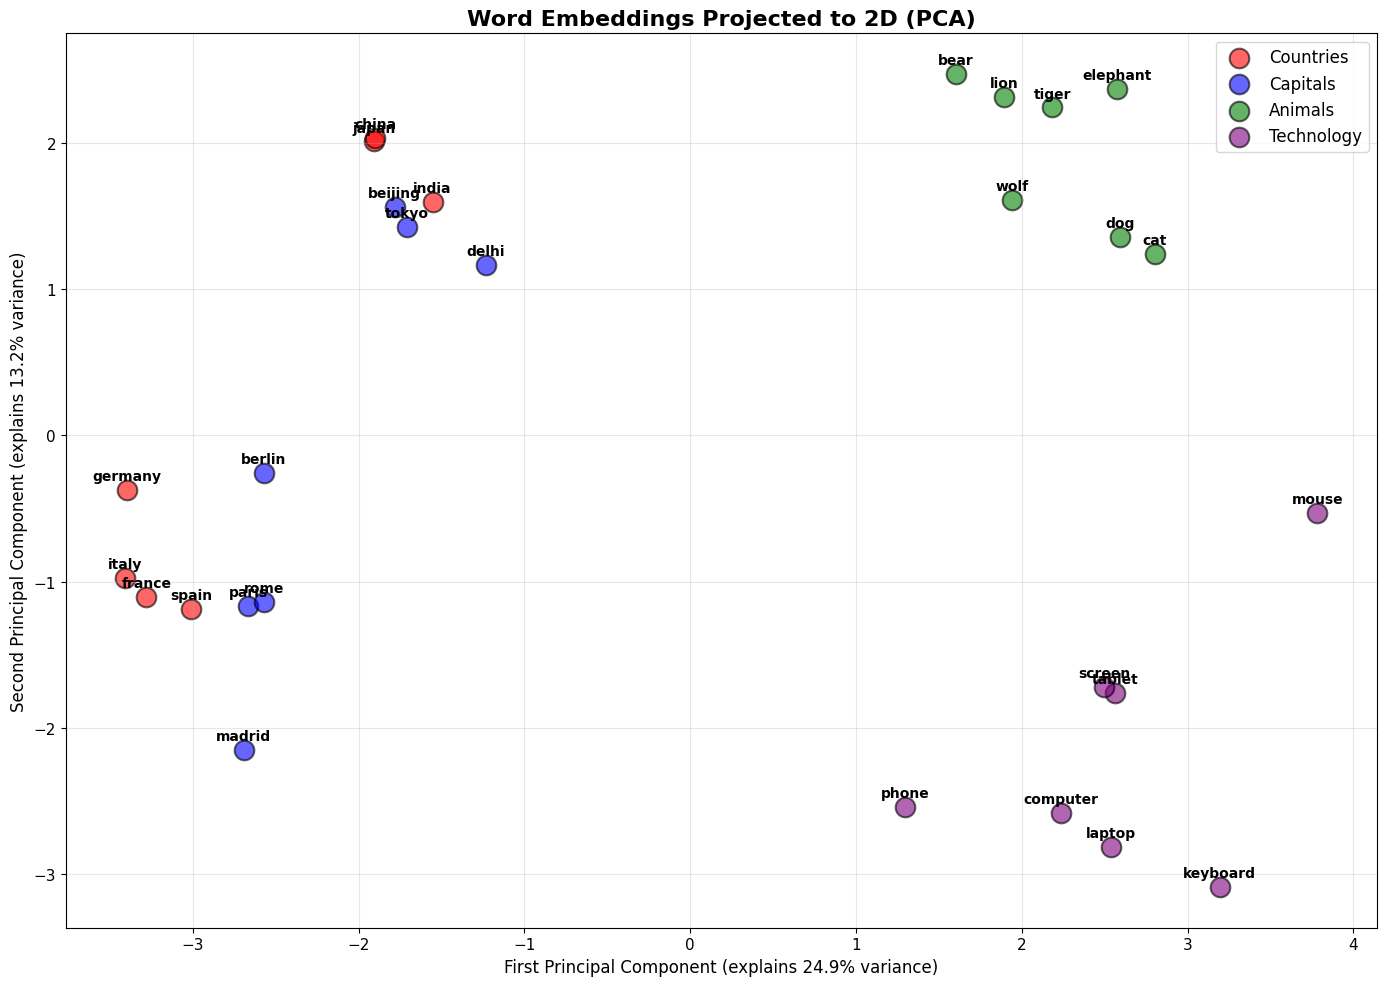

✅ Total variance explained by 2D projection: 38.1%
✅ Notice: Similar word types cluster together in the embedding space


In [ ]:
# Select word groups for visualization
word_groups = {
    'Countries': ['france', 'germany', 'italy', 'spain', 'japan', 'china', 'india'],
    'Capitals': ['paris', 'berlin', 'rome', 'madrid', 'tokyo', 'beijing', 'delhi'],
    'Animals': ['dog', 'cat', 'lion', 'tiger', 'elephant', 'bear', 'wolf'],
    'Technology': ['computer', 'laptop', 'phone', 'tablet', 'keyboard', 'mouse', 'screen']
}

# Collect all words and their vectors
all_words = []
all_vectors = []
word_labels = []
colors = []

color_map = {'Countries': 'red', 'Capitals': 'blue', 'Animals': 'green', 'Technology': 'purple'}

for group_name, words in word_groups.items():
    for word in words:
        if word in model:  # Check if word exists in vocabulary
            all_words.append(word)
            all_vectors.append(model[word])
            word_labels.append(group_name)
            colors.append(color_map[group_name])

# Convert to numpy array
vectors_array = np.array(all_vectors)

# Apply PCA to reduce to 2D
pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(vectors_array)

# Create visualization
plt.figure(figsize=(14, 10))

# Plot points by group
for group_name, color in color_map.items():
    # Get indices for this group
    indices = [i for i, label in enumerate(word_labels) if label == group_name]
    group_vectors = vectors_2d[indices]
    group_words = [all_words[i] for i in indices]
    
    # Plot scatter
    plt.scatter(group_vectors[:, 0], group_vectors[:, 1], 
                c=color, s=200, alpha=0.6, edgecolors='black', linewidth=1.5, label=group_name)
    
    # Annotate each point
    for i, word in enumerate(group_words):
        plt.annotate(word, (group_vectors[i, 0], group_vectors[i, 1]), 
                    fontsize=10, fontweight='bold', ha='center', va='bottom',
                    xytext=(0, 5), textcoords='offset points')

plt.xlabel(f'First Principal Component (explains {pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
plt.ylabel(f'Second Principal Component (explains {pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
plt.title('Word Embeddings Projected to 2D (PCA)', fontsize=16, fontweight='bold')
plt.legend(fontsize=12, loc='best')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f" Total variance explained by 2D projection: {sum(pca.explained_variance_ratio_)*100:.1f}%")
print(" Notice: Similar word types cluster together in the embedding space")